# Scratch baselines without SAM — CustomCNN, ResNet18, ViT
- Same preprocessing, cosine+warmup schedule, early stopping on AUROC.
- Final metrics shown at 0.5 and at a *recall‑first* operating point (screening).


In [14]:
# Make sure Python can import the package by name:
import sys
from pathlib import Path

# If the notebook is inside notebooks/, add the parent (project root) to sys.path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("sys.path[0] =", sys.path[0])

# Now import from the package by name (ABSOLUTE import, no leading dot)
from src import (
    DataCfg, TrainCfg, build_dataloaders, get_device, set_seed,
    build_custom_cnn, build_resnet18, build_vit_scratch, build_vit_pretrained,
    train_model, evaluate, choose_threshold_by_min_recall,
    summarize_at_threshold, plot_curve, plot_two_series, diag_plots,
    add_result, result_registry
)

import numpy as np, torch, time
set_seed(42)
DEVICE = get_device(); DEVICE


sys.path[0] = /Users/fouadaz/LearningFromUniversity/Learning/DeepLearning_2025/Deep-Learning-Project


device(type='mps')

In [ ]:
DATASET_DIR = Path("../Data/chest_xray")

data_cfg = DataCfg(
    dataset_dir=DATASET_DIR,
    image_size=224,
    batch_size=32,
    num_workers=2,
    val_ratio=0.20,
    balance_sampler=True,
    compute_norm_stats=False,
    gray_to_rgb=True
)

scratch_cfg = TrainCfg(
    epochs=100, patience=15, monitor="va_auroc",
    base_lr=0.1, weight_decay=0.001,
    clip_grad_norm=1.0, use_amp=False,
    use_sam=False, sam_rho=0.2,
    use_cosine=True, warmup_epochs=3, min_lr_mult=0.01,
    target_recall=0.95,
    llrd=False, head_lr_mult=1.0
)

train_loader, val_loader, test_loader, info = build_dataloaders(data_cfg, device=DEVICE)
print("Classes:", info["classes"])
print("Lens:", info["n_train"], info["n_val"], info["n_test"])
print("Train counts:", info["train_counts"])

# Class weights for imbalance
arr = np.array(info["train_counts"], dtype=float)
w = arr.sum() / (len(arr) * (arr + 1e-9))
class_weights = torch.tensor(w, dtype=torch.float32).to(DEVICE)
# OPTIONAL (avoid double-correction): uncomment next line when balance_sampler=True
class_weights = None


Classes: ['NORMAL', 'PNEUMONIA']
Lens: 4185 1047 624
Train counts: [1079, 3106]


[CustomCNN-scratch] epoch 01/100  tr_loss=0.4635  val_loss=2.9678  val_acc=0.2627  val_f1=0.0128  val_auroc=0.8578  (no_improve=0)
[CustomCNN-scratch] epoch 02/100  tr_loss=0.4528  val_loss=0.3328  val_acc=0.8567  val_f1=0.8960  val_auroc=0.9379  (no_improve=0)
[CustomCNN-scratch] epoch 03/100  tr_loss=0.4466  val_loss=0.3181  val_acc=0.8424  val_f1=0.9015  val_auroc=0.9404  (no_improve=0)
[CustomCNN-scratch] epoch 04/100  tr_loss=0.3981  val_loss=0.3195  val_acc=0.8730  val_f1=0.9082  val_auroc=0.9547  (no_improve=0)
[CustomCNN-scratch] epoch 05/100  tr_loss=0.3832  val_loss=0.5692  val_acc=0.8185  val_f1=0.8619  val_auroc=0.9510  (no_improve=1)
[CustomCNN-scratch] epoch 06/100  tr_loss=0.3920  val_loss=0.2709  val_acc=0.8816  val_f1=0.9244  val_auroc=0.9572  (no_improve=0)
[CustomCNN-scratch] epoch 07/100  tr_loss=0.3789  val_loss=0.2751  val_acc=0.8940  val_f1=0.9315  val_auroc=0.9609  (no_improve=0)
[CustomCNN-scratch] epoch 08/100  tr_loss=0.3698  val_loss=0.2689  val_acc=0.8873  

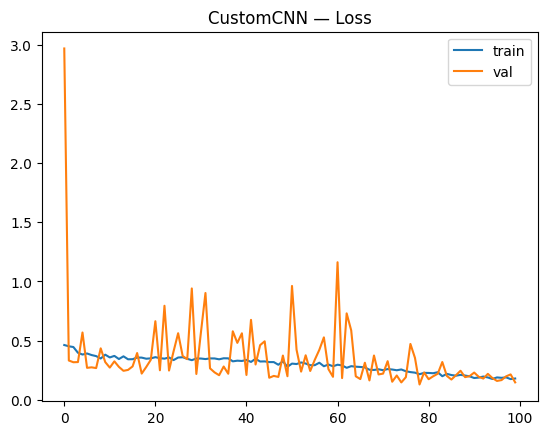

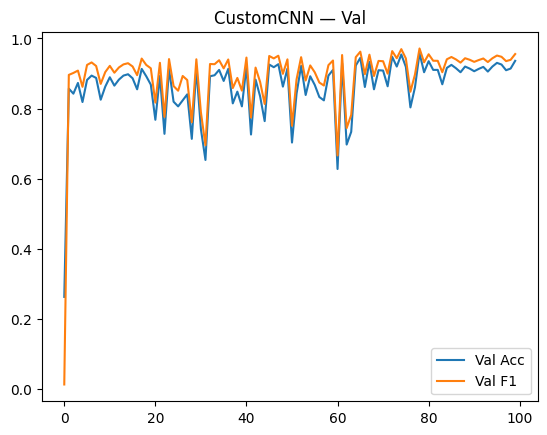

[CustomCNN @0.5] {'acc': 0.9247, 'precision': 0.9193, 'recall': 0.9641, 'f1': 0.9412, 'auroc': 0.9578, 'thr': 0.5}
[CustomCNN @Rec] {'acc': 0.9006, 'precision': 0.8727, 'recall': 0.9846, 'f1': 0.9253, 'auroc': 0.9578, 'thr': 0.237}


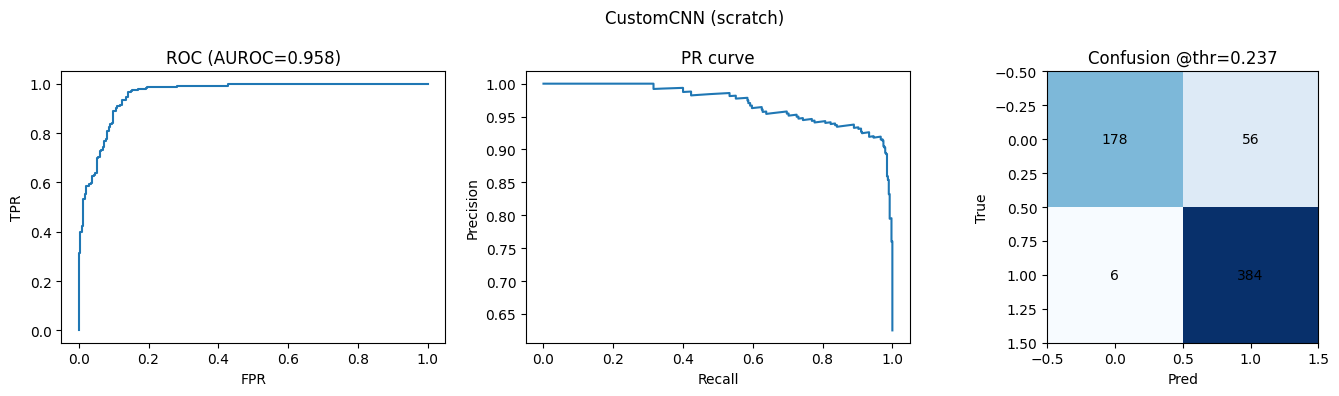

{'summary@0.5': {'acc': 0.9246794871794872,
  'precision': 0.9193154034229829,
  'recall': 0.9641025641025641,
  'f1': 0.9411764705882353,
  'auroc': 0.9577799693184309,
  'thr': 0.5},
 'summary@recall': {'acc': 0.9006410256410257,
  'precision': 0.8727272727272727,
  'recall': 0.9846153846153847,
  'f1': 0.9253012048192771,
  'auroc': 0.9577799693184309,
  'thr': 0.23700000000000002},
 'threshold': 0.23700000000000002,
 'time_sec': 8808.652324914932,
 'params': 481698}

In [16]:
cfg = scratch_cfg

cnn = build_custom_cnn(num_classes=2, width=32, dropout=0.0)
t0 = time.time()
cnn_tr, cnn_hist, cnn_time = train_model(
    cnn, train_loader, val_loader, DEVICE, arch="custom_cnn",
    epochs=cfg.epochs, base_lr=0.1, weight_decay=1e-3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.02,
    use_cosine=cfg.use_cosine, warmup_epochs=cfg.warmup_epochs, min_lr_mult=cfg.min_lr_mult,
    monitor=cfg.monitor, patience=cfg.patience, clip_grad_norm=cfg.clip_grad_norm,
    class_weights=class_weights, llrd=False, head_lr_mult=cfg.head_lr_mult, use_amp=cfg.use_amp,
    tag="CustomCNN-scratch"
)
cnn_time = time.time() - t0

plot_curve(cnn_hist['tr_loss'], cnn_hist['va_loss'], "CustomCNN — Loss")
plot_two_series(cnn_hist['va_acc'], "Val Acc", cnn_hist['va_f1'], "Val F1", "CustomCNN — Val")

va = evaluate(cnn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(cnn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[CustomCNN @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[CustomCNN @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("CustomCNN (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("CustomCNN (scratch)", cnn_tr, sum_05, sum_reca, threshold=thr, time_sec=cnn_time)


[ResNet18-scratch] epoch 01/90  tr_loss=0.5021  val_loss=4.0528  val_acc=0.2674  val_f1=0.0254  val_auroc=0.9725  (no_improve=0)
[ResNet18-scratch] epoch 02/90  tr_loss=0.6740  val_loss=1.9076  val_acc=0.6485  val_f1=0.6902  val_auroc=0.9471  (no_improve=1)
[ResNet18-scratch] epoch 03/90  tr_loss=0.5090  val_loss=0.3679  val_acc=0.7861  val_f1=0.8739  val_auroc=0.9655  (no_improve=2)
[ResNet18-scratch] epoch 04/90  tr_loss=0.4229  val_loss=0.3419  val_acc=0.8653  val_f1=0.9015  val_auroc=0.9718  (no_improve=3)
[ResNet18-scratch] epoch 05/90  tr_loss=0.4066  val_loss=0.2247  val_acc=0.9083  val_f1=0.9378  val_auroc=0.9641  (no_improve=4)
[ResNet18-scratch] epoch 06/90  tr_loss=0.3541  val_loss=0.1931  val_acc=0.9045  val_f1=0.9322  val_auroc=0.9833  (no_improve=0)
[ResNet18-scratch] epoch 07/90  tr_loss=0.3559  val_loss=0.5189  val_acc=0.7841  val_f1=0.8306  val_auroc=0.9776  (no_improve=1)
[ResNet18-scratch] epoch 08/90  tr_loss=0.3572  val_loss=0.3429  val_acc=0.8462  val_f1=0.8922  v

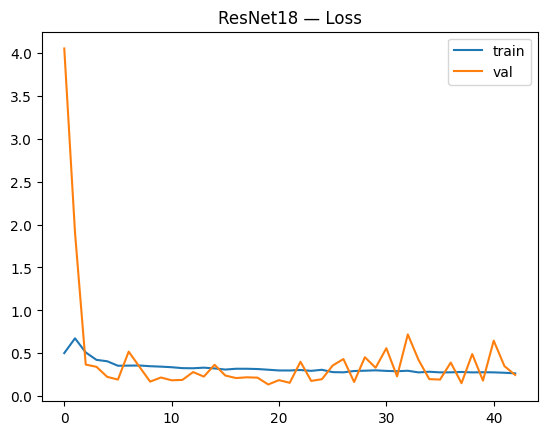

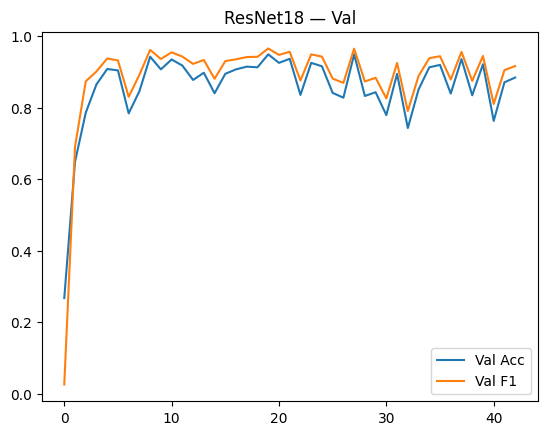

[ResNet18-scratch @0.5] {'acc': 0.8365, 'precision': 0.8025, 'recall': 0.9795, 'f1': 0.8822, 'auroc': 0.9416, 'thr': 0.5}
[ResNet18-scratch @Rec] {'acc': 0.8189, 'precision': 0.7844, 'recall': 0.9795, 'f1': 0.8712, 'auroc': 0.9416, 'thr': 0.457}


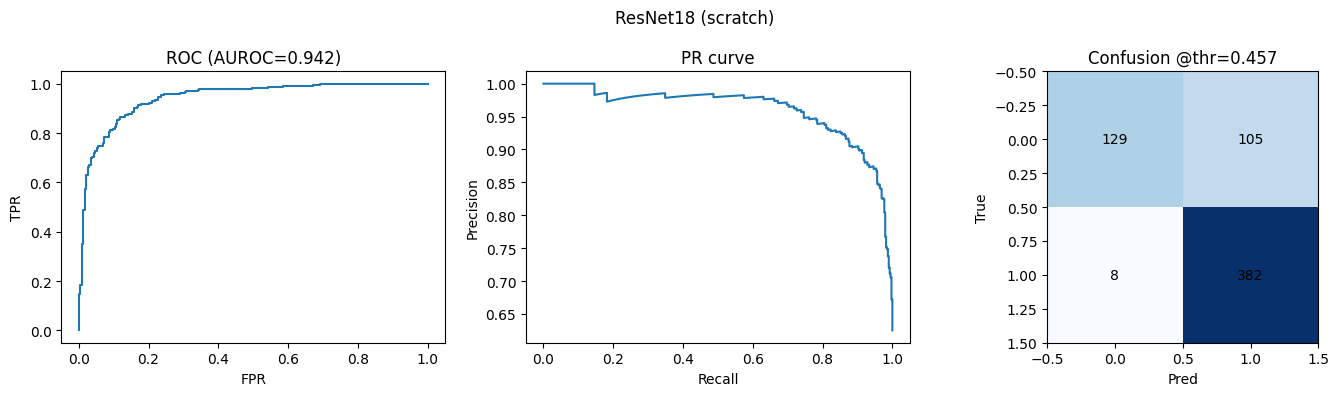

{'summary@0.5': {'acc': 0.8365384615384616,
  'precision': 0.8025210084033614,
  'recall': 0.9794871794871794,
  'f1': 0.8822170900692841,
  'auroc': 0.9416392724085032,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8189102564102564,
  'precision': 0.784394250513347,
  'recall': 0.9794871794871794,
  'f1': 0.87115165336374,
  'auroc': 0.9416392724085032,
  'thr': 0.457},
 'threshold': 0.457,
 'time_sec': 2714.2911100387573,
 'params': 11177538}

In [17]:
 
rn_time = time.time() - t0

plot_curve(rn_hist['tr_loss'], rn_hist['va_loss'], "ResNet18 — Loss")
plot_two_series(rn_hist['va_acc'], "Val Acc", rn_hist['va_f1'], "Val F1", "ResNet18 — Val")

va = evaluate(rn_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], cfg.target_recall)
te = evaluate(rn_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ResNet18-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ResNet18-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ResNet18 (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ResNet18 (scratch)", rn_tr, sum_05, sum_reca, threshold=thr, time_sec=rn_time)


[ViT-scratch] epoch 01/120  tr_loss=0.6095  val_loss=0.3815  val_acc=0.8338  val_f1=0.8755  val_auroc=0.9560  (no_improve=0)
[ViT-scratch] epoch 02/120  tr_loss=0.5574  val_loss=0.3454  val_acc=0.8634  val_f1=0.9009  val_auroc=0.9561  (no_improve=0)
[ViT-scratch] epoch 03/120  tr_loss=0.4782  val_loss=0.3359  val_acc=0.8653  val_f1=0.9027  val_auroc=0.9521  (no_improve=1)
[ViT-scratch] epoch 04/120  tr_loss=0.4712  val_loss=0.8614  val_acc=0.5349  val_f1=0.5444  val_auroc=0.9569  (no_improve=0)
[ViT-scratch] epoch 05/120  tr_loss=0.5136  val_loss=0.3188  val_acc=0.8691  val_f1=0.9062  val_auroc=0.9623  (no_improve=0)
[ViT-scratch] epoch 06/120  tr_loss=0.4422  val_loss=0.5720  val_acc=0.7727  val_f1=0.8208  val_auroc=0.9543  (no_improve=1)
[ViT-scratch] epoch 07/120  tr_loss=0.4208  val_loss=0.4847  val_acc=0.7755  val_f1=0.8226  val_auroc=0.9649  (no_improve=0)
[ViT-scratch] epoch 08/120  tr_loss=0.4335  val_loss=0.4521  val_acc=0.8118  val_f1=0.8569  val_auroc=0.9534  (no_improve=1)


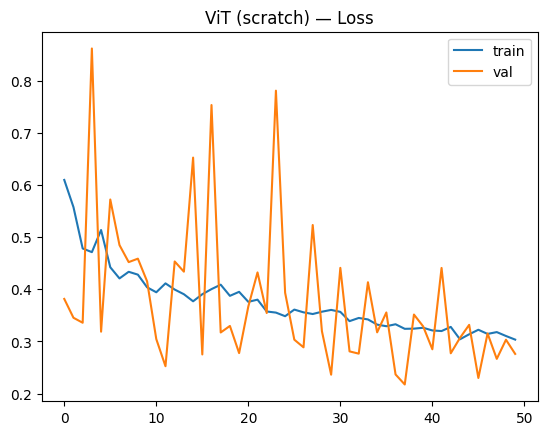

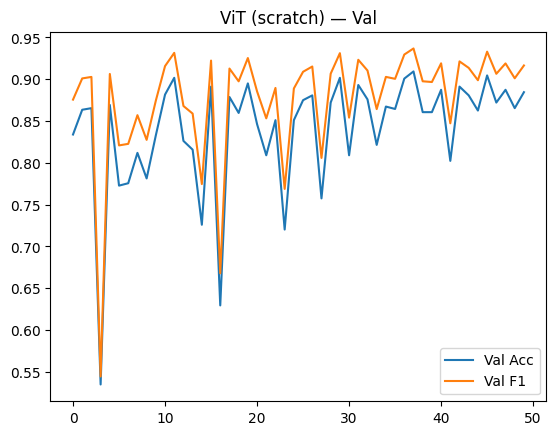

[ViT-scratch @0.5] {'acc': 0.8606, 'precision': 0.8976, 'recall': 0.8769, 'f1': 0.8872, 'auroc': 0.921, 'thr': 0.5}
[ViT-scratch @Rec] {'acc': 0.8189, 'precision': 0.7844, 'recall': 0.9795, 'f1': 0.8712, 'auroc': 0.921, 'thr': 0.1125}


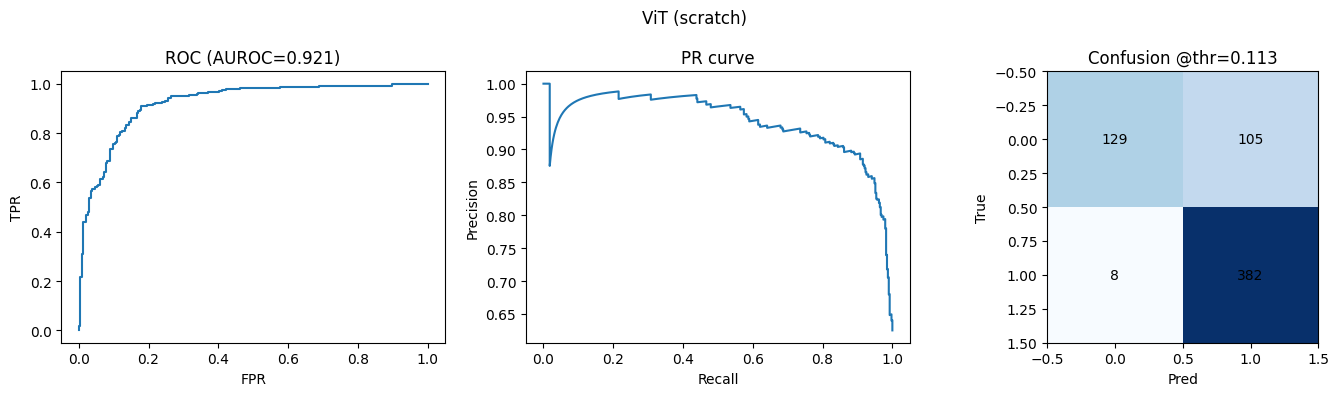

{'summary@0.5': {'acc': 0.8605769230769231,
  'precision': 0.8976377952755905,
  'recall': 0.8769230769230769,
  'f1': 0.8871595330739299,
  'auroc': 0.9210278325662941,
  'thr': 0.5},
 'summary@recall': {'acc': 0.8189102564102564,
  'precision': 0.784394250513347,
  'recall': 0.9794871794871794,
  'f1': 0.87115165336374,
  'auroc': 0.9210278325662941,
  'thr': 0.1125},
 'threshold': 0.1125,
 'time_sec': 5248.354040145874,
 'params': 21666434}

In [18]:
vit = build_vit_scratch(img_size=224, in_chans=3, num_classes=2,
                        embed_dim=384, depth=12, heads=6, patch=16, mlp_ratio=4.0, drop=0.1)
t0 = time.time()
vit_tr, vit_hist, vit_time = train_model(
    vit, train_loader, val_loader, DEVICE, arch="vit",
    epochs=120, base_lr=3e-4, weight_decay=0.3, label_smoothing=0.0,
    use_sam=False, sam_rho=0.2,
    use_cosine=True, warmup_epochs=5, min_lr_mult=0.01,
    monitor="va_auroc", patience=15, clip_grad_norm=1.0,
    class_weights=class_weights, llrd=False, head_lr_mult=10.0, use_amp=False,
    tag="ViT-scratch"
)
vit_time = time.time() - t0

plot_curve(vit_hist['tr_loss'], vit_hist['va_loss'], "ViT (scratch) — Loss")
plot_two_series(vit_hist['va_acc'], "Val Acc", vit_hist['va_f1'], "Val F1", "ViT (scratch) — Val")

va = evaluate(vit_tr, val_loader, DEVICE)
thr, rec, prec, f1 = choose_threshold_by_min_recall(va["targets"], va["probs"][:,1], scratch_cfg.target_recall)
te = evaluate(vit_tr, test_loader, DEVICE)
sum_05   = summarize_at_threshold(te["targets"], te["probs"][:,1], 0.5)
sum_reca = summarize_at_threshold(te["targets"], te["probs"][:,1], thr)
print("[ViT-scratch @0.5]", {k: round(v,4) for k,v in sum_05.items()})
print("[ViT-scratch @Rec]", {k: round(v,4) for k,v in sum_reca.items()})
diag_plots("ViT (scratch)", te["probs"], te["targets"], thr, auroc=te.get("auroc"))
add_result("ViT (scratch)", vit_tr, sum_05, sum_reca, threshold=thr, time_sec=vit_time)


In [19]:
import pandas as pd
from src import result_registry as RR

rows=[]
for name, d in RR.items():
    s = d.get("summary@recall", d.get("summary@0.5"))
    if not s: continue
    thr = d.get("threshold", s.get("thr", 0.5))
    rows.append({
        "Model": name,
        "Params (M)": round(d.get("params", 0)/1e6, 2) if d.get("params") else None,
        "Time (min)": round(d.get("time_sec", 0)/60, 2) if d.get("time_sec") else None,
        "Acc": round(s["acc"],4), "Prec": round(s["precision"],4),
        "Recall": round(s["recall"],4), "F1": round(s["f1"],4),
        "AUROC": round(s.get("auroc", float('nan')),4), "Thr": round(thr,3)
    })
df = pd.DataFrame(rows).sort_values(by=["F1","AUROC"], ascending=False).reset_index(drop=True)
display(df); print(df.to_string(index=False))


,Model,Params (M),Time (min),Acc,Prec,Recall,F1,AUROC,Thr
0,CustomCNN (scratch),0.48,146.81,0.9006,0.8727,0.9846,0.9253,0.9578,0.237
1,ResNet18 (scratch),11.18,45.24,0.8189,0.7844,0.9795,0.8712,0.9416,0.457
2,ViT (scratch),21.67,87.47,0.8189,0.7844,0.9795,0.8712,0.9210,0.113


              Model  Params (M)  Time (min)    Acc   Prec  Recall     F1  AUROC   Thr
CustomCNN (scratch)        0.48      146.81 0.9006 0.8727  0.9846 0.9253 0.9578 0.237
 ResNet18 (scratch)       11.18       45.24 0.8189 0.7844  0.9795 0.8712 0.9416 0.457
      ViT (scratch)       21.67       87.47 0.8189 0.7844  0.9795 0.8712 0.9210 0.113
